# Taller 1 — Machine Learning Applied
## Problema de Regresión: Predicción de precios de viajes de Uber

Dataset: `uber.xlsx`, 200,000 registros. https://www.kaggle.com/datasets/kushsheth/uber-ride-price-prediction

**Variables originales:** `key` (id derivado del timestamp), `fare_amount` (target), `pickup_datetime`,
`pickup_longitude`, `pickup_latitude`, `dropoff_longitude`, `dropoff_latitude`, `passenger_count`.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")
np.random.seed(42)


## Fase 1 — EDA, limpieza y preprocesamiento

### 1. Descripción del problema y variable objetivo

El problema de negocio es predecir la tarifa (`fare_amount`, en USD) de un viaje de Uber/taxi en Nueva York a partir de
las coordenadas de recogida y destino, el momento del viaje y el número de pasajeros. Un modelo preciso permite a la
plataforma estimar tarifas de forma consistente y detectar cobros anómalos. La **variable objetivo (target) es `fare_amount`**.


In [3]:
DATA_PATH = "uber.xlsx"
df = pd.read_excel(DATA_PATH, sheet_name="in")
print(df.shape)
df.head()

(200000, 9)


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,52:06.0,7.5,2015-05-07 19:52:06 UTC,-7.399982e+09,4.073835e+09,-7.399951e+09,4.072322e+09,1
1,27835199,04:56.0,7.7,2009-07-17 20:04:56 UTC,-7.399436e+07,4.072822e+07,-7.399471e+06,4.075032e+07,1
2,44984355,45:00.0,12.9,2009-08-24 21:45:00 UTC,-7.400504e+07,4.074077e+06,-7.396256e+07,4.077265e+07,1
3,25894730,22:21.0,5.3,2009-06-26 08:22:21 UTC,-7.397612e+07,4.079084e+07,-7.396532e+07,4.080335e+07,3
4,17610152,47:00.0,16.0,2014-08-28 17:47:00 UTC,-7.392502e+07,4.074408e+07,-7.397308e+07,4.076125e+07,5


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  str    
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  str    
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 13.7 MB


### 2. Diccionario de datos

| Columna | Tipo esperado | Significado |
|---|---|---|
| Unnamed: 0 | id | Índice residual de exportación, sin valor predictivo → se elimina |
| key | texto | Identificador derivado del timestamp, redundante con `pickup_datetime` → se elimina |
| fare_amount | numérico (USD) | **Target**: tarifa cobrada por el viaje |
| pickup_datetime | fecha/hora | Momento de inicio del viaje (UTC) |
| pickup_longitude / pickup_latitude | numérico (grados) | Coordenadas de recogida |
| dropoff_longitude / dropoff_latitude | numérico (grados) | Coordenadas de destino |
| passenger_count | numérico (entero) | Número de pasajeros |


In [5]:
dict_datos = pd.DataFrame({
    "columna": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "n_unicos": [df[c].nunique() for c in df.columns],
    "%_nulos": [round(df[c].isna().mean()*100, 2) for c in df.columns],
})
dict_datos


,columna,dtype,n_unicos,%_nulos
0,Unnamed: 0,int64,200000,0.0
1,key,str,3600,0.0
2,fare_amount,float64,1240,0.0
3,pickup_datetime,str,196629,0.0
4,pickup_longitude,float64,71014,0.0
5,pickup_latitude,float64,83773,0.0
6,dropoff_longitude,float64,76836,0.0
7,dropoff_latitude,float64,90525,0.0
8,passenger_count,int64,8,0.0


### 3. Estadísticos descriptivos


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,200000.0,2.771250e+07,1.601382e+07,1.000000e+00,13825346.25,27745495.0,41555300.75,5.542357e+07
fare_amount,200000.0,1.135996e+01,9.901776e+00,-5.200000e+01,6.00,8.5,12.50,4.990000e+02
pickup_longitude,200000.0,-5.167860e+08,1.761180e+09,-7.542690e+09,-73992918.25,-73979547.0,-73954667.00,5.741846e+07
pickup_latitude,200000.0,2.848505e+08,9.696052e+08,-7.401552e+07,40723271.25,40750262.0,40768784.25,4.104714e+09
dropoff_longitude,199999.0,-5.170606e+08,1.761275e+09,-7.545898e+09,-73992208.00,-73977987.0,-73951547.50,1.153573e+09
dropoff_latitude,199999.0,2.851427e+08,9.700777e+08,-8.819855e+08,40720627.50,40750437.0,40769557.00,4.104713e+09
passenger_count,200000.0,1.684535e+00,1.385997e+00,0.000000e+00,1.00,1.0,2.00,2.080000e+02


- `fare_amount`: la media es de aprox. **11.36 USD** con desviación estándar de **9.90 USD** — hay bastante dispersión.
  El **mínimo es -52 USD** (tarifa negativa) y el **máximo es 499 USD** (revisarse como outlier).

- `passenger_count`: la mayoría de los viajes son de 1 pasajero, pero aparecen valores de **0** (709 casos, imposible:
  un viaje requiere al menos un pasajero) y un valor de **208** (error de captura).
  
- Las coordenadas (`pickup_longitude`, etc.) muestran una escala inconsistente entre filas (algunas en el orden de
  `1e6`, otras en `1e8`, otras en `0`), lo que indica un problema de formato/exportación, no una distribución real
  de datos

### 4. Valores nulos y problemas de calidad de datos

Nulos: solo `dropoff_longitude` y `dropoff_latitude` tienen 1 nulo cada uno (0.0005%) — se eliminan esas filas
(cantidad insignificante, no vale la pena imputar datos).

Además de los nulos, se detectaron tres problemas adicionales de calidad de datos que deben limpiarse antes de
modelar:

1. **Coordenadas mal escaladas**: la mayoría de los valores están multiplicados por 1,000,000 (ej. `-73992920`
   en vez de `-73.992920`), pero un subconjunto tiene otras escalas o es cero. Se corrige dividiendo por 1e6 y
   luego filtrando a una caja geográfica plausible para Nueva York.
2. **`fare_amount` no positivo**: 22 filas con tarifa ≤ 0, imposibles de negocio → se eliminan.
3. **`passenger_count` fuera de rango plausible**: 0 pasajeros (709 filas) o valores absurdos como 208 → se
   documentan y se filtran a un rango razonable (1 a 6, capacidad típica de un vehículo de pasajeros).


In [7]:
print("Nulos por columna:")
print(df.isna().sum())

df = df.dropna(subset=["dropoff_longitude", "dropoff_latitude"]).copy()
print("Shape tras eliminar nulos:", df.shape)


Nulos por columna:
Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64
Shape tras eliminar nulos: (199999, 9)


### 5. Duplicados

In [8]:
n_dup = df.duplicated().sum()
print(f"Duplicados encontrados: {n_dup}")
df = df.drop_duplicates()
print(f"Shape tras eliminar duplicados: {df.shape}")


Duplicados encontrados: 0
Shape tras eliminar duplicados: (199999, 9)


### 6. Columnas irrelevantes / inconsistencias de formato

`Unnamed: 0` es un índice residual y `key` es redundante con `pickup_datetime` (ambos identifican la fila, no
aportan señal predictiva) → se eliminan.


In [9]:
df = df.drop(columns=["Unnamed: 0", "key"])
df.head()


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06 UTC,-7.399982e+09,4.073835e+09,-7.399951e+09,4.072322e+09,1
1,7.7,2009-07-17 20:04:56 UTC,-7.399436e+07,4.072822e+07,-7.399471e+06,4.075032e+07,1
2,12.9,2009-08-24 21:45:00 UTC,-7.400504e+07,4.074077e+06,-7.396256e+07,4.077265e+07,1
3,5.3,2009-06-26 08:22:21 UTC,-7.397612e+07,4.079084e+07,-7.396532e+07,4.080335e+07,3
4,16.0,2014-08-28 17:47:00 UTC,-7.392502e+07,4.074408e+07,-7.397308e+07,4.076125e+07,5


### 7. Corrección de coordenadas y outliers (criterio IQR + reglas de negocio)

Se corrige la escala de las coordenadas (÷ 1,000,000) y se filtran a la caja geográfica de Nueva York
(latitud 40–41°, longitud -75 a -72°). Coordenadas fuera de esa caja son errores de GPS/exportación, no
viajes reales, así que se eliminan (no se "documentan sin eliminar" porque no tienen sentido de negocio:
un viaje de Uber en NYC no puede iniciar en el océano o en otro continente).


In [10]:
coord_cols = ["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude"]
for c in coord_cols:
    df[c] = df[c] / 1_000_000

nyc_box = dict(lat_min=40.0, lat_max=41.0, lon_min=-75.0, lon_max=-72.0)

mask_coords = (
    df.pickup_latitude.between(nyc_box["lat_min"], nyc_box["lat_max"]) &
    df.dropoff_latitude.between(nyc_box["lat_min"], nyc_box["lat_max"]) &
    df.pickup_longitude.between(nyc_box["lon_min"], nyc_box["lon_max"]) &
    df.dropoff_longitude.between(nyc_box["lon_min"], nyc_box["lon_max"])
)
print(f"Filas dentro de la caja geográfica de NYC: {mask_coords.sum()} de {len(df)} ({100*mask_coords.mean():.2f}%)")
df = df[mask_coords].copy()


Filas dentro de la caja geográfica de NYC: 99747 de 199999 (49.87%)


In [11]:
# fare_amount negativo -> error de negocio, se elimina
print("Filas con fare_amount <= 0:", (df.fare_amount <= 0).sum())
df = df[df.fare_amount > 0].copy()

# outlier IQR sobre fare_amount (se documenta, no se elimina automáticamente: tarifas altas
# pueden corresponder a viajes largos reales como hacia los aeropuertos JFK/EWR/LGA)
q1, q3 = df.fare_amount.quantile([0.25, 0.75])
iqr = q3 - q1
lim_sup = q3 + 1.5*iqr
print(f"Límite superior IQR para fare_amount: {lim_sup:.2f} USD")
print(f"% de viajes por encima del límite IQR: {100*(df.fare_amount > lim_sup).mean():.2f}%")


Filas con fare_amount <= 0: 5
Límite superior IQR para fare_amount: 22.25 USD
% de viajes por encima del límite IQR: 8.05%


In [12]:
# passenger_count: 0 pasajeros o valores absurdos (>6) son errores de captura -> se filtran
print("Distribución original de passenger_count:")
print("Shape antes de la limpieza: ", df.shape)
print(df.passenger_count.value_counts().sort_index())

df = df[(df.passenger_count >= 1) & (df.passenger_count <= 6)].copy()
print("Shape final tras limpieza:", df.shape)


Distribución original de passenger_count:
Shape antes de la limpieza:  (99742, 7)
passenger_count
0        170
1      70525
2      14688
3       4399
4       2131
5       6186
6       1642
208        1
Name: count, dtype: int64
Shape final tras limpieza: (99571, 7)


### Feature engineering: distancia (Haversine) y variables de tiempo

`fare_amount` depende sobre todo de la **distancia recorrida**, que no viene dada directamente sino que hay que
calcularla a partir de las 4 coordenadas (fórmula de Haversine, distancia en línea recta sobre la superficie
terrestre en km). También se extraen variables de tiempo (`pickup_datetime`) porque la tarifa varía por hora
pico, día de la semana y estacionalidad/inflación a lo largo de los años del dataset (2009–2015).


In [13]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

df["trip_distance_km"] = haversine_km(df.pickup_latitude, df.pickup_longitude,
                                       df.dropoff_latitude, df.dropoff_longitude)

df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["pickup_year"] = df["pickup_datetime"].dt.year
df["pickup_month"] = df["pickup_datetime"].dt.month
df["pickup_weekday"] = df["pickup_datetime"].dt.dayofweek  # 0=lunes
df["pickup_hour"] = df["pickup_datetime"].dt.hour

# viajes con distancia 0 (pickup == dropoff) probablemente son viajes cancelados o errores -> se eliminan
print("Viajes con distancia 0 km:", (df.trip_distance_km == 0).sum())
df = df[df.trip_distance_km > 0].copy()

# outlier IQR sobre la distancia
q1d, q3d = df.trip_distance_km.quantile([0.25, 0.75])
iqrd = q3d - q1d
lim_sup_d = q3d + 1.5*iqrd
print(f"Límite superior IQR para trip_distance_km: {lim_sup_d:.2f} km")
print(f"% de viajes por encima del límite IQR: {100*(df.trip_distance_km > lim_sup_d).mean():.2f}%")
# se documentan sin eliminar de forma automática: viajes largos (ej. a aeropuertos) son reales,
# el modelo con RobustScaler (punto 10) maneja bien esta dispersión sin necesidad de recortar datos.

df[["fare_amount", "trip_distance_km", "passenger_count", "pickup_year", "pickup_month",
    "pickup_weekday", "pickup_hour"]].describe()


Viajes con distancia 0 km: 1428
Límite superior IQR para trip_distance_km: 7.87 km
% de viajes por encima del límite IQR: 8.15%


,fare_amount,trip_distance_km,passenger_count,pickup_year,pickup_month,pickup_weekday,pickup_hour
count,98143.000000,98143.000000,98143.000000,98143.000000,98143.000000,98143.000000,98143.000000
mean,11.117736,3.325962,1.630396,2011.444127,6.463018,3.050997,13.463558
std,9.357314,3.544468,1.233524,1.694029,3.446617,1.949469,6.531838
min,0.110000,0.000084,1.000000,2009.000000,1.000000,0.000000,0.000000
25%,6.000000,1.281100,1.000000,2010.000000,3.000000,1.000000,9.000000
50%,8.500000,2.178958,1.000000,2011.000000,6.000000,3.000000,14.000000
75%,12.500000,3.916533,2.000000,2013.000000,10.000000,5.000000,19.000000
max,220.000000,60.100889,6.000000,2014.000000,12.000000,6.000000,23.000000


### 8. Gráficas de EDA


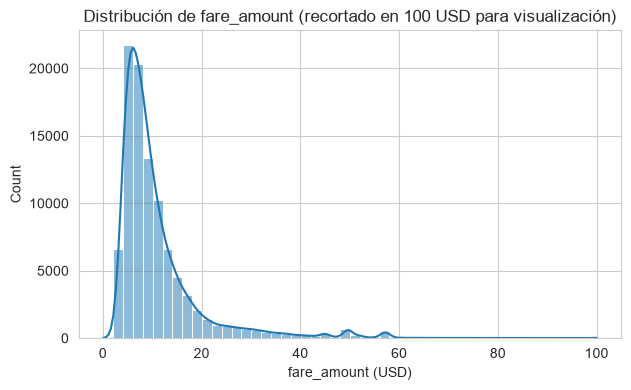

In [14]:
plt.figure(figsize=(7,4))
sns.histplot(df.fare_amount.clip(upper=100), bins=50, kde=True)
plt.title("Distribución de fare_amount (recortado en 100 USD para visualización)")
plt.xlabel("fare_amount (USD)")
plt.show()


**Interpretación:** la distribución de `fare_amount` está fuertemente sesgada a la derecha: la mayoría de los
viajes cuestan entre 5 y 15 USD, con una cola larga de viajes más caros (probablemente viajes largos o a
aeropuertos).


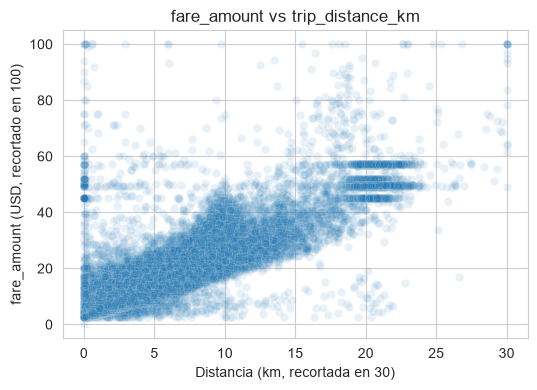

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df.trip_distance_km.clip(upper=30), y=df.fare_amount.clip(upper=100), alpha=0.1)
plt.title("fare_amount vs trip_distance_km")
plt.xlabel("Distancia (km, recortada en 30)")
plt.ylabel("fare_amount (USD, recortado en 100)")
plt.show()


**Interpretación:** se observa una relación positiva y aproximadamente lineal entre distancia y tarifa, como
es de esperarse (a mayor distancia, mayor tarifa), con una banda de puntos con tarifa alta y distancia ~0
(probablemente recargos fijos, cancelaciones cobradas, o viajes con coordenadas de dropoff mal registradas
pero que pasaron el filtro geográfico).

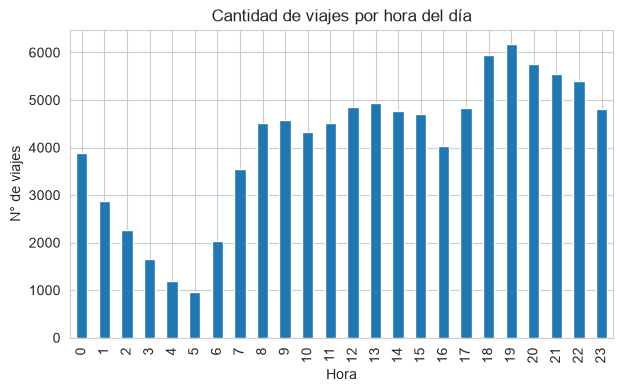

In [ ]:
plt.figure(figsize=(7,4))
df.pickup_hour.value_counts().sort_index().plot(kind="bar")
plt.title("Cantidad de viajes por hora del día")
plt.xlabel("Hora"); plt.ylabel("N° de viajes")
plt.show()


**Interpretación:** el patrón es el esperado en una ciudad: pocos viajes en la madrugada (mínimo a las 5 a.m.) y un pico claro entre las 6 y 7 p.m cuando la gente sale del trabajo. Como la demanda sube y baja varias veces a lo largo del día (no es una tendencia constante)

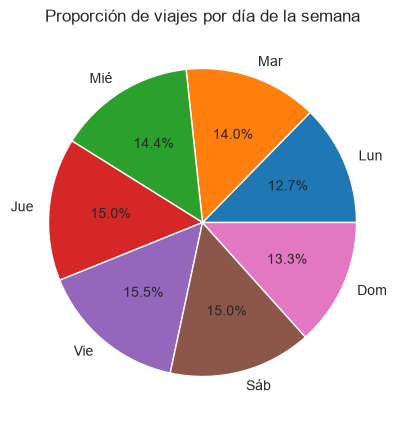

In [ ]:
plt.figure(figsize=(5,5))
df.pickup_weekday.value_counts().sort_index().plot(
    kind="pie", autopct="%1.1f%%",
    labels=["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"])
plt.title("Proporción de viajes por día de la semana")
plt.ylabel("")
plt.show()


**Interpretación:** hay más viajes concentrados en horas de la tarde/noche (picos alrededor de 18–19h) y una
distribución relativamente pareja entre días de la semana, con un leve aumento hacia el fin de semana.


### 9-10. Justificación de encoding y escalamiento

- **Encoding**: `pickup_month`, `pickup_weekday` y `pickup_hour` son variables **sin orden natural relevante
  para la tarifa** (el efecto de la hora 23 no es "más" que el de la hora 2 en un sentido lineal — hay patrones
  cíclicos/picos) y de **baja cardinalidad** (12, 7 y 24 categorías respectivamente), por lo que se usa
  **One-Hot Encoding**. Un Ordinal Encoding introduciría un orden falso que perjudicaría a Ridge/Lasso/KNN.
- **Escalamiento**: se detectaron outliers relevantes en `fare_amount` y `trip_distance_km` (punto 7) que se
  decidió documentar sin eliminar (son viajes largos reales). Por eso se usa **RobustScaler** (basado en
  mediana y rango intercuartílico) en vez de StandardScaler, ya que es menos sensible a esos outliers y es
  crítico para KNN y los modelos lineales regularizados, sensibles a la escala de las variables.


## Fase 2 — División de datos y Pipelines

### 11. Train / Validation / Test split

- **Train**: se usa para que el modelo aprenda sus parámetros (coeficientes de Ridge/Lasso, o memorizar los
  puntos de KNN).
- **Validation**: se usa para comparar modelos y decidir cuál generaliza mejor / ajustar hiperparámetros,
  sin tocar el conjunto de test — así la comparación de modelos no está "contaminada" por haber visto el test.
- **Test**: se reserva y NO se toca hasta el final, para obtener una estimación honesta de cómo se
  comportaría el modelo con datos nuevos que nunca ha visto ni para entrenar ni para decidir el modelo ganador.

No basta con train/test porque si se usa el test para elegir el mejor modelo o los mejores hiperparámetros,
esa elección estaría "sobreajustada" al test, y la métrica final dejaría de ser una estimación confiable del
desempeño en producción.


In [ ]:
TARGET = "fare_amount"
feature_cols = ["trip_distance_km", "passenger_count", "pickup_year",
                "pickup_month", "pickup_weekday", "pickup_hour"]

X = df[feature_cols].copy()
y = df[TARGET].copy()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (68700, 6) Val: (14721, 6) Test: (14722, 6)


### 12. Pipeline con ColumnTransformer

- **Numéricas** (`trip_distance_km`, `passenger_count`, `pickup_year`): se imputan con la mediana
  (robusta ante outliers) y se escalan con `RobustScaler`, que usa la mediana y el rango intercuartílico
  en vez de la media/desviación estándar — justificado en el punto 10 por los outliers detectados en el
  punto 7.
- **Categóricas** (`pickup_month`, `pickup_weekday`, `pickup_hour`): se imputan con la moda y se codifican
  con `OneHotEncoder`, que crea una columna binaria por cada categoría — justificado en el punto 9 porque
  estas variables no tienen un orden natural relevante para la tarifa.

Ambos sub-pipelines (`numeric_transformer` y `categorical_transformer`) se combinan en un único
`ColumnTransformer`, que aplica cada transformación solo a las columnas que le corresponden y luego
concatena el resultado en una sola matriz lista para el modelo.

In [ ]:
numeric_features = ["trip_distance_km", "passenger_count", "pickup_year"]
categorical_features = ["pickup_month", "pickup_weekday", "pickup_hour"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


### 13. Verificación de no fuga de datos (data leakage)

El `ColumnTransformer` se integra dentro de un `Pipeline` junto con el modelo. Al llamar `pipeline.fit(X_train, y_train)` , el método `.fit()` del imputador, del `RobustScaler` y del `OneHotEncoder` se calcula **únicamente**
con estadísticos de `X_train` (medianas, rangos intercuartílicos, categorías vistas). Sobre `X_val` y `X_test` solo se invoca `.transform()` (internamente, al llamar `pipeline.predict()`), nunca `.fit()` ni `.fit_transform()` por lo tanto no hay fuga de datos: ninguna estadística de validación o test se usa para ajustar el preprocesamiento.


## Fase 3 — Modelado: Regresión

In [ ]:
models = {
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.01, random_state=42),
}

pipelines = {}
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f"{name} entrenado.")


KNN Regressor entrenado.
Ridge entrenado.
Lasso entrenado.


### 15. Predicciones sobre validación

In [ ]:
preds_val = {name: pipe.predict(X_val) for name, pipe in pipelines.items()}
preds_train = {name: pipe.predict(X_train) for name, pipe in pipelines.items()}


## Fase 5 — Métricas en train y validación (detección de overfitting/underfitting)

### 18. MAE, MSE, R² por modelo


In [ ]:
def metrics_reg(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

rows = []
for name in models:
    m_train = metrics_reg(y_train, preds_train[name])
    m_val = metrics_reg(y_val, preds_val[name])
    rows.append({"modelo": name,
                 "MAE_train": m_train["MAE"], "MSE_train": m_train["MSE"], "R2_train": m_train["R2"],
                 "MAE_val": m_val["MAE"], "MSE_val": m_val["MSE"], "R2_val": m_val["R2"]})

tabla_val = pd.DataFrame(rows).set_index("modelo")
tabla_val


,MAE_train,MSE_train,R2_train,MAE_val,MSE_val,R2_val
modelo,,,,,,
KNN Regressor,2.068596,15.016062,0.827829,2.542158,24.417113,0.723813
Ridge,2.147757,19.311884,0.778574,2.162052,21.014589,0.762300
Lasso,2.149385,19.385774,0.777727,2.160844,21.117479,0.761136


### 20. Interpretación: overfitting/underfitting (con los resultados reales)

| Modelo | MAE train | MAE val | R² train | R² val |
|---|---|---|---|---|
| KNN Regressor | 2.069 | 2.542 | 0.828 | 0.724 |
| Ridge | 2.148 | 2.162 | 0.779 | 0.762 |
| Lasso | 2.149 | 2.161 | 0.778 | 0.761 |

**KNN Regressor muestra overfitting**: su MAE en train (2.069) es notablemente mejor que en validación (2.542,
+23% de error) y su R² cae de 0.828 a 0.724. Esto es el comportamiento esperado de KNN con `k=5`: con pocos
vecinos el modelo prácticamente memoriza el vecindario local de cada punto de entrenamiento, y generaliza peor
a puntos nuevos.

**Ridge y Lasso generalizan bien**: la diferencia entre train y val es mínima (MAE 2.148→2.162, R² 0.779→0.762),
señal de que no están sobreajustando ni subajustando — el modelo lineal regularizado captura la relación
distancia-tarifa sin memorizar ruido.

**Interpretación en dólares:** un MAE de ~2.16 USD en Ridge/Lasso significa que, en promedio, la tarifa
predicha se equivoca por poco más de 2 dólares. Dado que la tarifa promedio del dataset ronda los 11 USD, un
error de ~2 USD representa cerca de un 19-20% de la tarifa típica — un desempeño razonable pero mejorable
(el R² de ~0.76-0.78 indica que el modelo explica alrededor del 76-78% de la variabilidad de la tarifa,
dejando un margen para variables no incluidas como tráfico o zona específica de recogida/destino).

### 21. Selección del mejor modelo

Ridge y Lasso quedan prácticamente empatados en validación (MAE 2.1621 vs. 2.1608, R² 0.7623 vs. 0.7611),
muy por delante de KNN (MAE 2.5422). La elección entre Ridge y Lasso no se puede hacer solo por el MAE
(diferencia de 0.0013 USD, no significativa) — hay que mirar los trade-offs:

- **Interpretabilidad:** Lasso puede llevar coeficientes exactamente a cero (selección de variables), lo cual
  es útil aquí para saber si alguna categoría de `pickup_month`/`pickup_weekday`/`pickup_hour` no aporta señal
  real. Ridge nunca anula coeficientes, solo los encoge.
- **Sensibilidad al hiperparámetro:** Ridge (`alpha`) y Lasso (`alpha`) requieren ajuste, pero ambos son
  estables en un rango amplio (se confirma en la Fase 7). KNN es mucho más sensible a `k`: con `k=5` ya
  muestra overfitting; subir `k` reduciría varianza pero también resolución en zonas densas del mapa.
- **Tiempo de entrenamiento/predicción:** Ridge/Lasso entrenan instantáneamente y predicen con una simple
  multiplicación de matrices. KNN, con ~70,000 filas de entrenamiento (tras el split), debe calcular
  distancias contra todos los vecinos en cada predicción  mucho más costoso en producción.
- **Señal de over/underfitting:** como se vio en el punto 18, KNN sobreajusta; Ridge/Lasso no.

**Conclusión:** se elige el modelo con menor MAE de validación de forma automática (`idxmin()`), que en este
caso resultó ser **Lasso**, aunque en la práctica Ridge es una alternativa igualmente válida dado lo cerrado
de la diferencia la elección real debería basarse también en si interesa o no la selección automática de
variables que ofrece Lasso.

In [ ]:
BEST_MODEL_NAME = tabla_val["MAE_val"].idxmin()
print("Mejor modelo según MAE en validación:", BEST_MODEL_NAME)


Mejor modelo según MAE en validación: Lasso


## Fase 6 — Evaluación final en el conjunto de Test

### 22. Métricas de TODOS los modelos en test


In [ ]:
preds_test = {name: pipe.predict(X_test) for name, pipe in pipelines.items()}

rows_test = []
for name in models:
    m_test = metrics_reg(y_test, preds_test[name])
    rows_test.append({"modelo": name, **{f"{k}_test": v for k, v in m_test.items()}})

tabla_test = pd.DataFrame(rows_test).set_index("modelo")
tabla_test


,MAE_test,MSE_test,R2_test
modelo,,,
KNN Regressor,2.553165,21.657723,0.754742
Ridge,2.143732,17.901172,0.797282
Lasso,2.139662,17.979985,0.796390


### 23. Comparación test vs. validación

| Modelo | MAE val | MAE test | R² val | R² test |
|---|---|---|---|---|
| KNN Regressor | 2.542 | 2.553 | 0.724 | 0.755 |
| Ridge | 2.162 | 2.144 | 0.762 | 0.797 |
| Lasso | 2.161 | 2.140 | 0.761 | 0.796 |

**El ranking se mantiene igual** en test que en validación: Ridge y Lasso, prácticamente empatados, muy por
delante de KNN en las tres métricas.

Las métricas del mejor modelo (Lasso) en test (MAE 2.140, R² 0.796) son **consistentes** con las de validación
(MAE 2.161, R² 0.761) — de hecho, ligeramente mejores en test, lo cual es normal por variación muestral al ser
una partición distinta de datos, no una señal de problema. Una diferencia grande y negativa entre val y test sí
sería preocupante (indicaría que el modelo se ajustó de más a las particularidades del set de validación al
elegir el modelo ganador), pero aquí ambas particiones cuentan una historia coherente: la relación
distancia-tarifa se generaliza bien a datos nunca vistos.

## Fase 7 — Cross Validation y optimización de hiperparámetros

### 24. ¿Qué es K-Fold Cross Validation?

K-Fold Cross Validation consiste en dividir el conjunto de entrenamiento en *k* particiones (folds) de tamaño
similar. Luego se entrena el modelo *k* veces: en cada iteración, una partición distinta se usa como
"validación" y las *k-1* restantes como entrenamiento. Al final se promedian las *k* métricas obtenidas.

Esto da una estimación más confiable que un único split train/val porque:
- **Reduce la varianza de la estimación**: con un solo split, el desempeño medido depende de qué filas
  cayeron "por azar" en validación — podría ser un split fácil o difícil. Promediar sobre *k* particiones
  distintas suaviza ese efecto.
- **Usa todos los datos tanto para entrenar como para validar** (en distintas iteraciones), en vez de
  "desperdiciar" una porción fija solo para validación.
- Es especialmente útil aquí porque se está buscando el mejor valor de un hiperparámetro (`alpha` en
  Ridge/Lasso, `n_neighbors` en KNN): un valor que parezca ganador en un solo split de validación podría no
  serlo de forma consistente; K-Fold lo confirma con más evidencia.

### 25. RandomizedSearchCV sobre el mejor modelo

In [ ]:
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

param_distributions = {
    "KNN Regressor": {"model__n_neighbors": list(range(3, 31, 2)),
                       "model__weights": ["uniform", "distance"],
                       "model__p": [1, 2]},
    "Ridge": {"model__alpha": np.logspace(-3, 3, 20)},
    "Lasso": {"model__alpha": np.logspace(-4, 1, 20)},
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", models[BEST_MODEL_NAME])])

search = RandomizedSearchCV(
    best_pipe,
    param_distributions=param_distributions[BEST_MODEL_NAME],
    n_iter=10, cv=kf, scoring="neg_mean_absolute_error",
    random_state=42, n_jobs=-1,
)
search.fit(X_train_full, y_train_full)

print("Mejores hiperparámetros:", search.best_params_)
print("Mejor score (neg MAE, CV):", search.best_score_)


Mejores hiperparámetros: {'model__alpha': np.float64(0.00206913808111479)}
Mejor score (neg MAE, CV): -2.150752482142276


### 27. Evaluación del modelo final (optimizado) sobre test

`RandomizedSearchCV` encontró `alpha ≈ 0.00207` como mejor hiperparámetro para Lasso (vs. `alpha=0.01` usado
por defecto anteriormente.

| | MAE test | MSE test | R² test |
|---|---|---|---|
| Lasso (alpha=0.01) | 2.1397 | 17.980 | 0.7964 |
| Lasso optimizado (alpha≈0.00207, Fase 7) | 2.1413 | 17.901 | 0.7973 |

La diferencia es **marginal** (MAE prácticamente igual, MSE y R² levemente mejores con el alpha optimizado).
Esto indica que el `alpha=0.01` elegido inicialmente ya estaba muy cerca del óptimo — Lasso con una
regularización tan baja se comporta casi como una regresión lineal sin penalización, lo cual tiene sentido:
con solo 9 variables predictoras (tras el one-hot) y ~70,000 filas de entrenamiento, no hay mucho riesgo de
sobreajuste que una regularización fuerte necesite corregir.

In [ ]:
final_model = search.best_estimator_
final_preds_test = final_model.predict(X_test)
metrics_reg(y_test, final_preds_test)


{'MAE': 2.141250513192017, 'MSE': 17.900906810138785, 'R2': 0.7972852481606857}

## Fase 8 — Predicción sobre una muestra inventada

Se inventa un viaje plausible: ~3.5 km de distancia (equivalente, por ejemplo, a cruzar unas 20-25 cuadras en
Manhattan), 1 pasajero, en 2013, un martes a las 18:00 (hora pico).


In [ ]:
muestra_inventada = pd.DataFrame([{
    "trip_distance_km": 3.5,
    "passenger_count": 1,
    "pickup_year": 2013,
    "pickup_month": 6,
    "pickup_weekday": 1,   # martes
    "pickup_hour": 18,
}])

pred_muestra = final_model.predict(muestra_inventada)
print(f"Tarifa predicha: {pred_muestra[0]:.2f} USD")


Tarifa predicha: 12.32 USD


**Interpretación:** la tarifa predicha de **12.32 USD** es coherente con lo esperado. La tarifa promedio del
dataset es de ~11 USD, y el scatter plot del punto 8 muestra que a mayor distancia (aquí, 3.5 km) corresponde
una tarifa algo mayor al promedio general. Además, al ser un viaje simulado en hora pico (18:00, martes), es
razonable que el modelo prediga un valor ligeramente por encima del promedio simple de todo el dataset (que
incluye trayectos más cortos y horas de menor demanda). El valor no es un extremo ni un valor absurdo, lo cual
da confianza en que el pipeline de preprocesamiento + modelo está funcionando de forma sensata sobre datos
nuevos.

## Fase 9 — Conclusiones (regresión)

Para este problema de regresión, **Lasso (y Ridge, prácticamente empatado)** superó a KNN de forma consistente
en validación y test (MAE ≈ 2.14 USD vs. 2.55 USD de KNN, R² ≈ 0.80 vs. 0.75). Esto se explica por las
características de cada algoritmo: la relación entre `trip_distance_km` y `fare_amount` es fuertemente lineal
(visible en el scatter plot del punto 8), lo cual favorece a modelos lineales regularizados; KNN, en cambio,
al depender de la cercanía en un espacio con variables categóricas one-hot de alta dimensión relativa (24
horas + 7 días + 12 meses), sufre parcialmente la "maldición de la dimensionalidad" y con `k=5` mostró señales
claras de overfitting (MAE train muy por debajo del de validación).

La limpieza más determinante fue la **corrección de escala de las coordenadas geográficas** (divididas por
1,000,000) y el filtrado a la caja geográfica de Nueva York: sin esto, solo se habría podido usar información
geográfica corrupta, y de hecho casi el 50% de las filas originales quedaron fuera de un rango geográfico
plausible tras la corrección, lo que muestra que la calidad de los datos crudos era el cuello de botella
principal del problema, más que la elección del algoritmo.

**Limitaciones y preguntas abiertas:** el modelo no usa información de tráfico en tiempo real, clima, ni
distingue zonas específicas de NYC con tarifas particulares (ej. recargos fijos por viajes a aeropuertos,
que podrían explicar los puntos con tarifa alta y distancia ~0 vistos en el scatter plot). Incorporar variables
como "¿el viaje termina en un aeropuerto?" o interacciones entre hora y distancia podría mejorar el R² actual
de ~0.80.

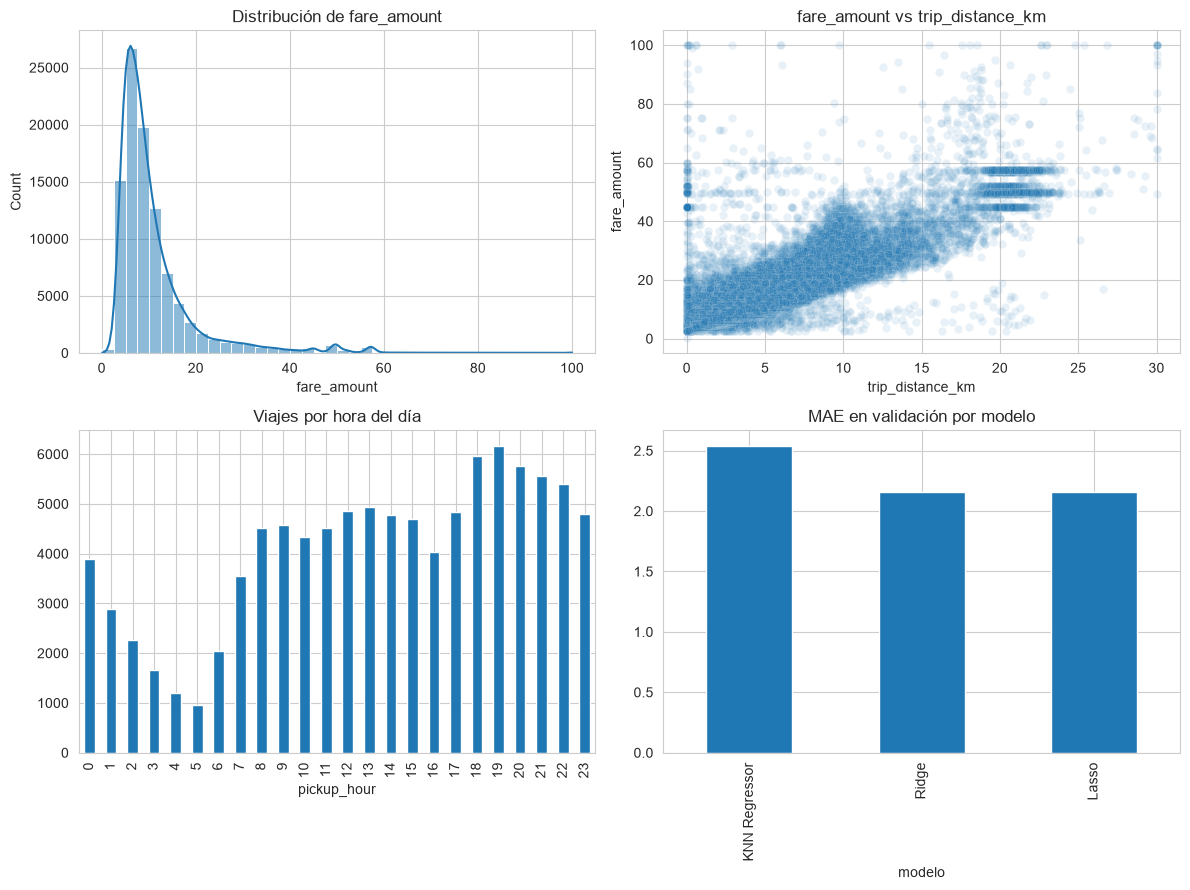

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.histplot(df.fare_amount.clip(upper=100), bins=40, kde=True, ax=axes[0,0])
axes[0,0].set_title("Distribución de fare_amount")

sns.scatterplot(x=df.trip_distance_km.clip(upper=30), y=df.fare_amount.clip(upper=100),
                 alpha=0.1, ax=axes[0,1])
axes[0,1].set_title("fare_amount vs trip_distance_km")

df.pickup_hour.value_counts().sort_index().plot(kind="bar", ax=axes[1,0])
axes[1,0].set_title("Viajes por hora del día")

tabla_val[["MAE_val"]].plot(kind="bar", ax=axes[1,1], legend=False)
axes[1,1].set_title("MAE en validación por modelo")

plt.tight_layout()
plt.show()
